# **Airbnb Market Intelligence & Business Analysis**

## Project Objective

The objective of this project is to analyze Airbnb records to uncover pricing trends, customer preferences, host performance and the influence of property characteristics on listing prices.

The analysis is being performed using the cleaned dataset generated during the data cleaning stage and aims to derive practical business insights through exploratory data analysis (EDA) and data visualization.

---

## Libraries used

- Pandas
- NumPy
- Matplotlib

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [115]:
df=pd.read_csv('airbnb_cleaned.csv')

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13838 entries, 0 to 13837
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          13838 non-null  object 
 1   rating        9198 non-null   float64
 2   reviews       11211 non-null  float64
 3   host_name     13464 non-null  object 
 4   address       13838 non-null  object 
 5   amenities     13838 non-null  object 
 6   safety_rules  13838 non-null  object 
 7   house_rules   13838 non-null  object 
 8   price         13838 non-null  int64  
 9   guests        13838 non-null  int64  
 10  bedrooms      13118 non-null  float64
 11  beds          13795 non-null  float64
 12  bathrooms     10388 non-null  float64
 13  check_in      13011 non-null  object 
 14  check_out     11312 non-null  object 
 15  country       13838 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 1.7+ MB


In [117]:
df.head()

,name,rating,reviews,host_name,address,amenities,safety_rules,house_rules,price,guests,bedrooms,beds,bathrooms,check_in,check_out,country
0,Perla bungalov,4.71,64.0,Mehmetcan,"Kartepe, Kocaeli, Turkey","Mountain view,Valley view,Lake access,Kitchen,...","󹀁,Airbnb's COVID-19 safety practices apply,No ...","Check-in: Flexible,Check out: 12:00 pm,Pets ar...",8078,2,2.0,2.0,1.0,Flexible,12:00 pm,Turkey
1,Authentic Beach Architect Sheltered Villa with...,NaN,NaN,Fatih,"Kaş, Antalya, Turkey","Kitchen,Wifi,Dedicated workspace,Free parking ...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: 4:00 pm - 11:00 pm,Check out: 10:00 ...",4665,4,2.0,2.0,2.0,4:00 pm - 11:00 pm,10:00 am,Turkey
2,cottages sataplia,4.85,68.0,Giorgi,"Imereti, Georgia","Mountain view,Kitchen,Wifi,Dedicated workspace...","󹀁,Airbnb's COVID-19 safety practices apply,No ...","Check-in: After 1:00 pm,Check out: 12:00 pm,Se...",5991,4,1.0,1.0,1.0,After 1:00 pm,12:00 pm,Georgia
3,Sapanca Breathable Bungalow,5.00,13.0,Melih,"Sapanca, Sakarya, Turkey","Mountain view,Valley view,Kitchen,Wifi,Free pa...","󹀁,Airbnb's COVID-19 safety practices apply,No ...","Check-in: After 2:00 pm,Check out: 12:00 pm,No...",11339,4,1.0,1.0,1.0,After 2:00 pm,12:00 pm,Turkey
4,Bungalov Ev 2,NaN,NaN,Arp Sapanca,"Sapanca, Sakarya, Turkey","Kitchen,Wifi,Free parking on premises,TV,Air c...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: After 2:00 pm,Check out: 12:00 pm,No...",6673,2,1.0,1.0,1.0,After 2:00 pm,12:00 pm,Turkey


In [118]:
df.describe()

,rating,reviews,price,guests,bedrooms,beds,bathrooms
count,9198.000000,11211.000000,1.383800e+04,13838.000000,13118.000000,13795.000000,10388.000000
mean,4.858176,46.385425,2.453747e+04,5.336609,2.348453,2.328017,2.702060
std,0.139418,73.395248,8.670399e+04,3.899567,2.447594,2.412913,2.386882
min,3.000000,1.000000,3.930000e+02,1.000000,1.000000,1.000000,0.000000
25%,4.780000,4.000000,4.089000e+03,2.000000,1.000000,1.000000,1.000000
50%,4.890000,18.000000,8.516000e+03,4.000000,1.000000,1.000000,2.000000
75%,4.980000,56.000000,1.734600e+04,6.000000,3.000000,3.000000,5.000000
max,5.000000,1003.000000,3.906351e+06,16.000000,50.000000,50.000000,50.000000


### Key Findings from Initial Inspection

- The cleaned dataset contains 13,838 Airbnb listings.
- Price varies considerably, indicating a wide range of property types.
- Ratings and reviews contain missing values because not every listing has been reviewed.
- The dataset includes host information, amenities, property characteristics, and pricing details, making it suitable for market and customer behavior analysis.

## Pricing Analysis

How are Airbnb listing prices distributed, and are there any significant pricing outliers?

In [119]:
df['price'].describe().round(2)

,price
count,13838.00
mean,24537.47
std,86703.99
min,393.00
25%,4089.00
50%,8516.00
75%,17346.00
max,3906351.00


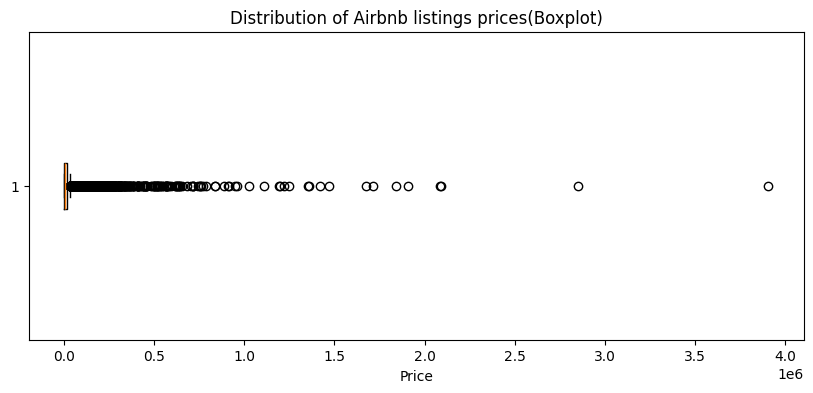

In [120]:
plt.figure(figsize=(10,4))
plt.boxplot(df['price'], vert=False)

plt.title('Distribution of Airbnb listings prices(Boxplot)')
plt.xlabel('Price')
plt.show()

In [121]:
q1=df['price'].quantile(0.25)
q3=df['price'].quantile(0.75)

iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr

print('Lower : ',lower)
print('Upper : ',upper)

Lower :  -15796.5
Upper :  37231.5


In [122]:
outliers = df[(df["price"]<lower)] | df[((df["price"]>upper))]
print("Number of outliers : ",len(outliers))

Number of outliers :  1561


Yes, there are quite a number of outliers in the listings' price data that have been calculated and also can be observed in the plotted boxplot

In [123]:
price_df=df[df['price']<=upper]

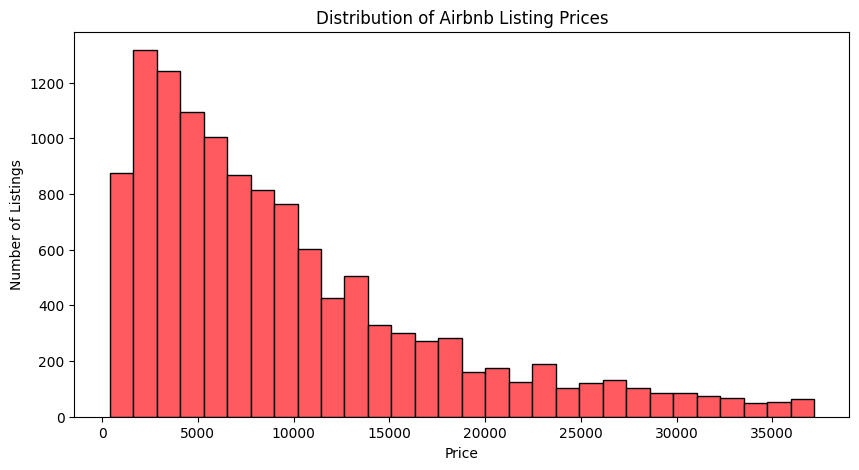

In [124]:
plt.figure(figsize=(10,5))
plt.hist(price_df['price'],bins=30, edgecolor='black', color='#FF5A60')
plt.title("Distribution of Airbnb Listing Prices")
plt.xlabel('Price')
plt.ylabel('Number of Listings')
plt.show()

To improve the readability of the histogram, only listings within the IQR upper limit were visualized.

All statistical analyses were performed on the complete dataset.

### How are Airbnb listings distributed across different price segments?

In [125]:
labels=['Budget','Standard','Premium','Luxury']

df["price_category"] = pd.cut(
    df["price"],
    bins=[0, 10000, 20000, 50000, np.inf],
    labels=labels
)

df[['price_category','price']].sample(10)

,price_category,price
3387,Standard,14043
811,Budget,8277
6350,Luxury,95268
7908,Standard,13713
5169,Budget,1642
35,Budget,7418
3503,Budget,3652
10901,Budget,1817
7818,Premium,32648
1883,Budget,3424


In [126]:
price_counts=(df["price_category"].value_counts().sort_index())
print(price_counts)

price_category
Budget      7860
Standard    2993
Premium     1815
Luxury      1170
Name: count, dtype: int64


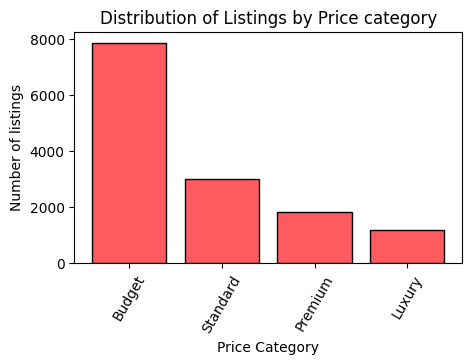

In [127]:
plt.figure(figsize=(5,3))
plt.bar(price_counts.index, price_counts.values,
        color='#FF5A60',
        edgecolor='black')

plt.title('Distribution of Listings by Price category')
plt.xlabel("Price Category")
plt.ylabel('Number of listings')

plt.xticks(rotation=60)

plt.show()

In [128]:
price_percent=df["price_category"].value_counts(normalize=True).sort_index().mul(100).round(2)
print(price_percent)

price_category
Budget      56.80
Standard    21.63
Premium     13.12
Luxury       8.45
Name: proportion, dtype: float64


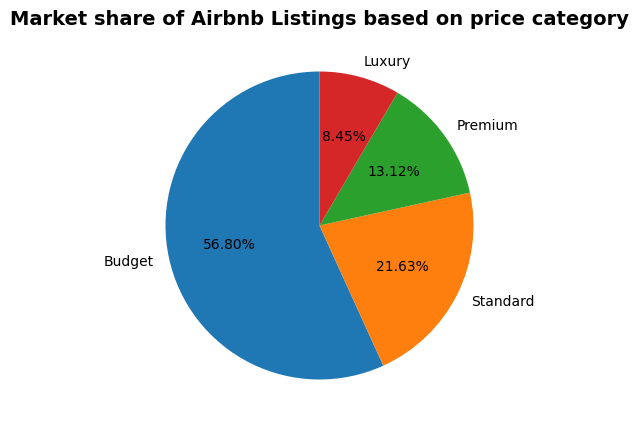

In [129]:
plt.figure(figsize=(5,5))
plt.pie(
    price_percent,
    labels=price_percent.index,
    autopct='%1.2f%%',
    startangle=90
)
plt.title('Market share of Airbnb Listings based on price category',
          fontsize=14,
          fontweight='bold')
plt.show()

### Observation

More than half of all Airbnb listings i.e. 56.8% fall under the Budget category (₹0–₹10,000). Standard-priced listings account for 21.6%, while Premium for 13.12% and Luxury for 8.45% of the market.

### Business Insight

The Airbnb marketplace is dominated by budget-friendly accommodations. Higher-priced properties represent a smaller share of the market, suggesting that demand is likely concentrated in affordable listings.

### Recommendation

Hosts entering the Airbnb market may find greater competition in the Budget segment due to its large number of listings. Premium and Luxury hosts should focus on differentiating their properties through superior amenities, location, or unique experiences rather than competing solely on price.



---
---
## Customer Satisfaction Analysis


### How are Airbnb listings rated, and what does the distribution of ratings reveal about customer satisfaction?

In [130]:
rating_df=df.dropna(subset=['rating'])

Since some listings have null values for `rating`, we will exclude them for this analysis.

In [131]:
rating_df['rating'].describe()

,rating
count,9198.000000
mean,4.858176
std,0.139418
min,3.000000
25%,4.780000
50%,4.890000
75%,4.980000
max,5.000000


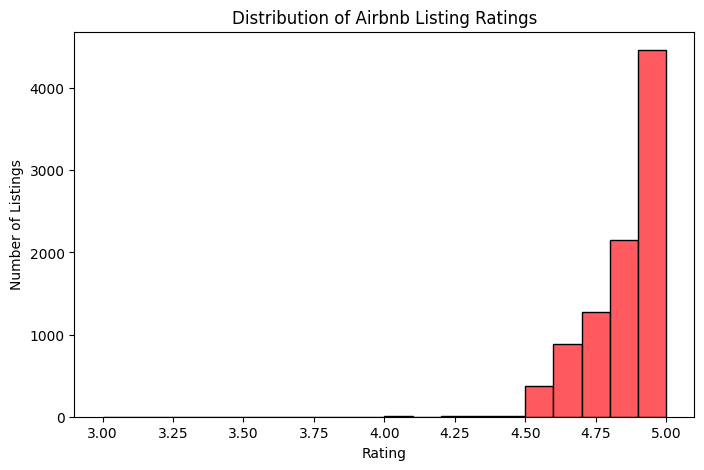

In [132]:
plt.figure(figsize=(8,5))

plt.hist(
    rating_df["rating"],
    bins=20,
    edgecolor="black",
    color='#FF5A60'
)

plt.title("Distribution of Airbnb Listing Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Listings")

plt.show()

### Observation

We can see that most Airbnb listings are concentrated between 4.50 and 5.00 rating.

This indicates that high rated listings dominate our dataset

### Business Insight

The high concentration of ratings near the upper limit proposes that the business of Airbnb generally provides strong guest satisfaction.

Though, it may also mean that poorly performing listings generally don't receive reviews or are removed from the platform from time to time.

### Recommendation

Hosts should maintain a high service quality to remain competitive in the market, as majority of the listings have excellent ratings.

---
---

### Do higher-priced Airbnb listings receive better ratings?

In [133]:
avg_rating=(rating_df
            .groupby('price_category',observed=False)['rating']
            .mean().round(2))
print(avg_rating)

price_category
Budget      4.84
Standard    4.88
Premium     4.88
Luxury      4.89
Name: rating, dtype: float64


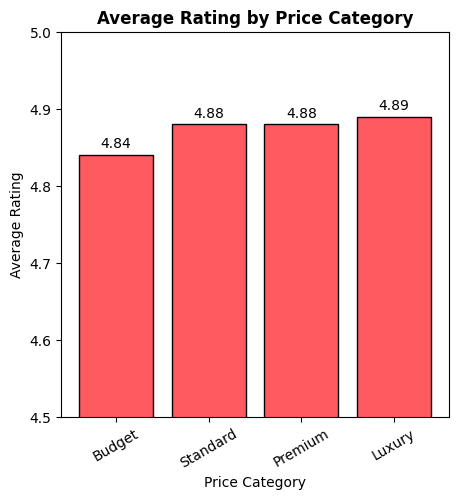

In [134]:
plt.figure(figsize=(5,5))

plt.bar_label(
    (plt.bar(avg_rating.index,
        avg_rating.values,
        color='#FF5A60',
        edgecolor="Black")),
    label_type='edge',padding=3)
plt.title('Average Rating by Price Category',fontweight='bold')
plt.xlabel("Price Category")
plt.xticks(rotation=30)
plt.ylabel("Average Rating")
plt.ylim(4.5,5)

plt.show()

### Observation

Average rating increased just slightly with higher price categories. Budget listings have an average of **4.84** rating while Standard and Premium have an average of **4.88** rating and Luxury listings have the highest average of **4.89**.

### Business Insight

Although Luxury listings have the highest average rating. The differences seen across the price categories are very small.

This suggests that guests generally rate Airbnb listings highly regardless of their price range categories. Therefore, price doesn't seem to be a strong differentiator of customer satisfaction.



### Recommendation

Hosts should focus more on maintaining their service quality rather than relying solely on pricing, as customer ratings is seen to consistently high across all price segments.

---
---

### Does a higher listing price lead to better customer ratings?

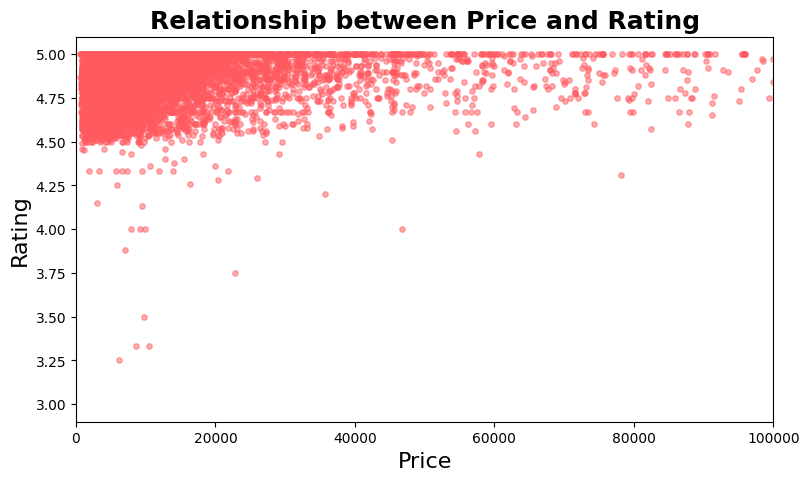

In [135]:
plt.figure(figsize=(9,5))
plt.scatter(df['price'],
            df['rating'],
            alpha=0.5,
            s=15,
            color='#FF5A60')

plt.title('Relationship between Price and Rating',
          fontweight='bold',
          fontsize=18)
plt.xlabel('Price',fontsize=16)
plt.ylabel('Rating',fontsize=16)
plt.xlim(0,100000)

plt.show()

In [136]:
correlation = rating_df["price"].corr(rating_df["rating"])

print(f"Correlation between Price and Rating: {correlation:.2f}")

Correlation between Price and Rating: 0.08


### Observation

The scatter plot shows that listings across all the price ranges generally receive high ratings. There is no clear upward or downward trend. Also, the correlation value is **0.08** i.e. very weak that signifies that customer ratings remain consistently high regardless of listing price.

### Business Insight

Higher price listings do not necessarily receive better ratings. While luxury listings are seen to have slightly higher ratings, guest satisfaction appears to depend on factors other than pricing.

### Recommendation

Hosts should focus on improving overall guest experience instead of increasing prices to receive better ratings. Providing quality service is likely to have more impact on customer satisfaction.

---
---


## Property Analysis

### Do properties that accommodate more guests charge higher prices?

In [137]:
guests_df=df.dropna(subset=['guests'])

In [138]:
guests_df.groupby('guests',observed =False)['price'].describe()

,count,mean,std,min,25%,50%,75%,max
guests,,,,,,,,
1,137.0,4362.211679,6854.949762,462.0,1289.00,2307.0,3686.00,46218.0
2,3965.0,8275.844893,21809.407991,590.0,2816.00,5477.0,9646.00,1221575.0
3,1310.0,7554.383969,19264.614592,669.0,2799.00,4963.5,8412.75,635123.0
4,2759.0,11134.944183,15603.146096,393.0,4576.50,8144.0,13092.00,411371.0
5,736.0,12901.361413,16289.986835,655.0,5659.50,9534.0,15094.00,325762.0
6,1548.0,21865.148579,46038.679293,698.0,6867.00,11978.0,21768.25,705472.0
7,265.0,17261.411321,19321.776014,876.0,7050.00,13760.0,21326.00,238171.0
8,817.0,41840.925337,83120.299881,759.0,9757.00,18621.0,40674.00,912051.0
9,208.0,24452.927885,31540.057005,913.0,7796.50,14292.0,30436.50,218053.0


In [139]:
avg_price_guests=(guests_df
                  .groupby("guests", observed=False)['price']
                  .mean()
                  .round(2))

print(avg_price_guests)

guests
1       4362.21
2       8275.84
3       7554.38
4      11134.94
5      12901.36
6      21865.15
7      17261.41
8      41840.93
9      24452.93
10     62058.34
11     50473.50
12     86482.06
13     62396.86
14     91412.79
15     41444.55
16    111495.44
Name: price, dtype: float64


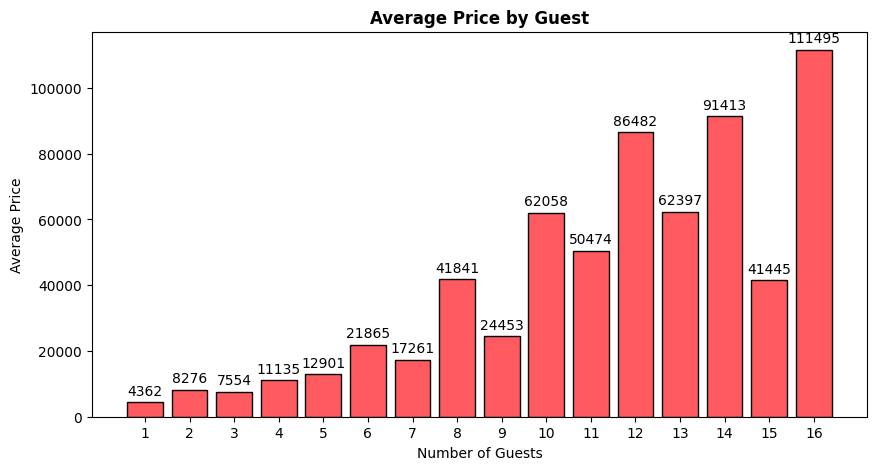

In [140]:
plt.figure(figsize=(10,5))

plt.bar_label((plt.bar(avg_price_guests.index.astype(str),
                       avg_price_guests.values,
                       edgecolor='black',
                       color='#FF5A60')),
              fmt='%.0f',
              padding=3)

plt.title('Average Price by Guest', fontweight='bold')
plt.xlabel('Number of Guests')
plt.ylabel('Average Price')

plt.show()

### Observation

Listings that accommodate more guests generally have higher average price, indicating that larger listings has higher rental prices.

### Business Insights

Guest Capacity can be seen as an important factor in the pricing of Airbnb listings. Larger listings that can probably serve families and groups, allow hosts to charge higher rental prices.

### Recommendation

Hosts with larger properties can consider competitive pricing based on guest capacity while also ensuring that the facilities provided by them justify the higher pricing.

---
---

### How does the number of bedrooms influence Airbnb listing prices?

In [141]:
bedroom_df=df.dropna(subset='bedrooms')

In [142]:
avg_price_bedroom=(
    bedroom_df
    .groupby('bedrooms', observed=False)
    ['price'].mean()
    .round(2)
    )
print(avg_price_bedroom)

bedrooms
1.0        8668.98
2.0       13967.59
3.0       25846.67
4.0       44967.10
5.0       70574.77
6.0      104149.41
7.0       99645.33
8.0      130772.52
9.0      132756.32
10.0     130381.48
11.0     246332.21
12.0     163254.75
13.0     300774.07
14.0     179255.33
15.0     229892.00
16.0      51267.91
17.0     495214.50
18.0      45436.50
19.0     259783.00
20.0     113180.71
21.0     161896.50
22.0     884704.50
23.0     262736.00
24.0      43520.50
25.0       5208.00
26.0      22254.00
27.0      87642.00
28.0       6081.00
30.0      22766.00
34.0     570770.00
35.0    1715043.00
50.0       5251.67
Name: price, dtype: float64


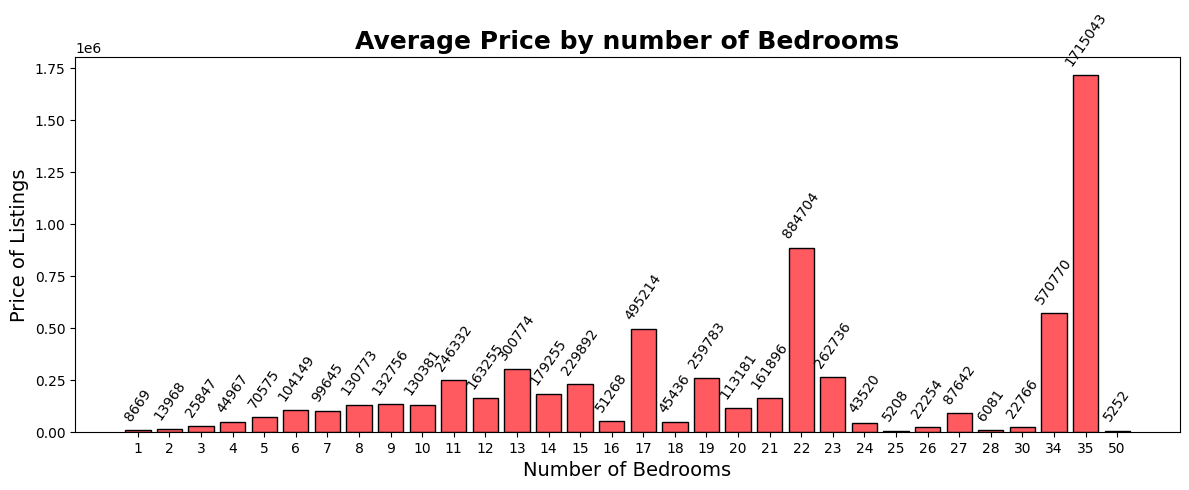

In [143]:
plt.figure(figsize=(12,5))

bedroom_labels = [str(int(b)) for b in avg_price_bedroom.index]

plt.bar_label(
    (plt.bar(
    bedroom_labels,
    avg_price_bedroom.values,
    edgecolor='#000000',
    color='#FF5A60')),
              fmt='%.0f',
              padding=5,
              rotation=55)

plt.title('Average Price by number of Bedrooms',fontsize=18,fontweight='bold')
plt.xlabel('Number of Bedrooms',fontsize=14)
plt.ylabel('Price of Listings', fontsize=14)
plt.tight_layout()
plt.show()

### Observation
Average listing prices generally increase as the number of bedrooms increases. However, properties with **22, 34 and 35** bedrooms have exceptionally high average pricing, clearly making them outliers.

## Business Insight

Larger properties typically demand higher prices due to their greater capacity. The sudden spike in the average pricing for some segments suggest that they belong to the luxury segments.

### Recommendation

Host should price their listings by comparing them with prices of properties with similar number of bedrooms. Also, luxury properties should be evaluated separately, as they can be outliers in the pair.

---
---

### Does the number of bathrooms affect Airbnb listing prices?

In [144]:
bathroom_df=df.dropna(subset=['bathrooms'])

avg_price_bathroom=(bathroom_df
                    .groupby('bathrooms', observed=False)
                    ['price'].mean().round(2)
                    )
avg_price_bathroom

,price
bathrooms,
0.0,10912.00
1.0,10802.47
2.0,19099.90
3.0,31186.99
4.0,49916.72
5.0,49604.97
6.0,107949.40
7.0,112523.94
8.0,117774.03


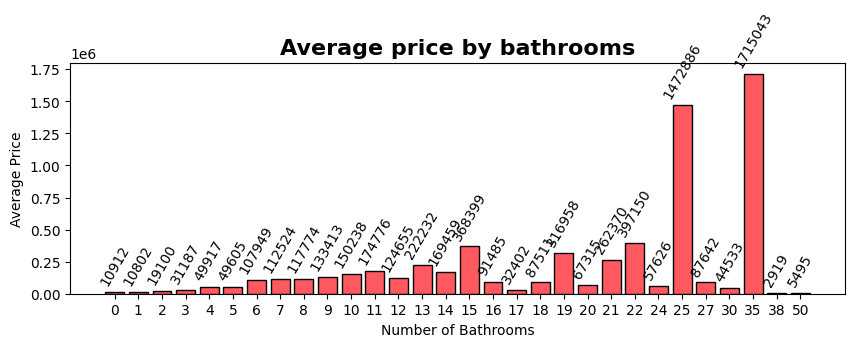

In [145]:
plt.figure(figsize=(10,3))

bathroom_label=[str(int(bath)) for bath in avg_price_bathroom.index]
plt.bar_label((plt.bar(bathroom_label,
                       avg_price_bathroom.values,
                       color='#FF5A60',
                       edgecolor='black')),
              fmt='%.0f',
              padding=3,
              rotation=60)
plt.title('Average price by bathrooms',fontweight='bold', fontsize=16)
plt.xlabel('Number of Bathrooms')
plt.ylabel('Average Price')

plt.show()

### Observation

Average listing prices genrally increase with the number of bathrooms. However, properties with **25 and 35 bathrooms** have exceptionally high average prices making them complete outliers.

### Business Insight

Listings with more bathrooms typically offer greater comfort and can accommodate larger groups, therefore costing larger prices. The sharp spike of average price at higher bathroom count shows luxury properties.

### Recommendation

Hosts should consider the number of bathrooms when pricing their listings, but this comparison is only valid for smaller sized properties. The luxury listings should be analyzed separately to avoid pricing confusions.

---
---


## Location Analysis
### Which country have the highest average Airbnb listing prices?


In [146]:
top_20_countries=df.groupby('country', observed=False).size().sort_values(ascending=False).head(20)
top_20_countries

,0
country,
India,2833
Italy,1325
Greece,975
Thailand,875
Turkey,541
France,500
Morocco,411
Georgia,376
Indonesia,361


Above is the number of Airbnb listings in each country.

In [147]:
avg_price_country=(df.groupby('country', observed=False)
                   ['price'].mean().round(2))
avg_price_country

,price
country,
Albania,4749.75
Argentina,10647.00
Armenia,6939.43
Australia,26848.92
Austria,19934.21
...,...
Uruguay,9828.50
Uzbekistan,3502.00
Vanuatu,15718.00


In [148]:
df['country'].value_counts().describe()

,count
count,120.000000
mean,115.316667
std,316.146599
min,1.000000
25%,3.000000
50%,16.000000
75%,77.750000
max,2833.000000


Looking at the range of number of listings in Airbnb across countries. Filtering countries having less than 50 listings seems valid for finding top 10 countries based on listings average price.

In [149]:
country_stats = (
    df.groupby("country", observed=False)
      .agg(
          average_price=("price", "mean"),
          listings=("country", "count")
      )
      .round(2)
)

country_stats = (
    country_stats[country_stats["listings"] >= 50]
    .sort_values("average_price", ascending=False)
    .head(10)
)

country_stats

,average_price,listings
country,,
Switzerland,137270.61,61
United Arab Emirates,117531.72,53
Italy,53906.56,1325
Thailand,50993.71,875
United States,42325.17,196
Indonesia,38712.96,361
Croatia,36286.80,179
Greece,36252.98,975
Turkey,32176.79,541


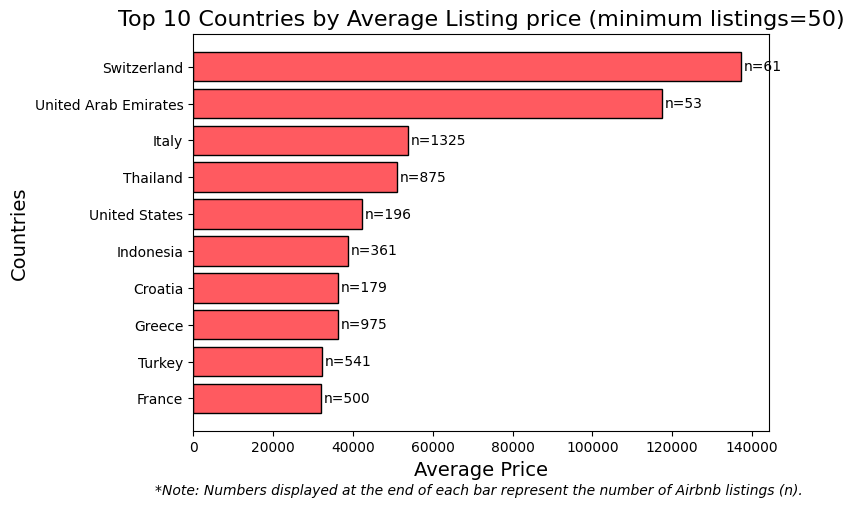

In [150]:
plt.figure(figsize=(8,5))

plt.bar_label((plt.barh(country_stats.index,
                       country_stats['average_price'],
                       color='#FF5A60',
                       edgecolor='black')),
              padding=2,
              labels=[f"n={x}" for x in country_stats['listings']])
plt.title("Top 10 Countries by Average Listing price (minimum listings=50)" , fontsize=16)
plt.figtext(
    0.2, -0.001,
    "*Note: Numbers displayed at the end of each bar represent the number of Airbnb listings (n).",
    fontsize=10,
    style="italic")
plt.ylabel('Countries',fontsize=14)
plt.xlabel('Average Price',fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Observation

Switzerland and United Arab Emirates have the highest Average Airbnb listing price among countries with atleast 50 listings. Italy, Thailand, Greece, Turkey and France can also be seen in the top 10 while having significantly more number of listings, making their average more representative of their markets.

### Business Insight

Airbnb pricing varies considerably across countries due to differences in tourism demand, conditions of locality and also property prices. Countries with larger counts of listings provide more reliable info for understanding the respective trends.

### Recommendation

Hosts should standarize their pricing in consideration to listings within their own country rather than straightaway going for the global averages.

---
---

## Host analysis

### Which hosts manage the largest number of Listings? *(Top 10)*

In [151]:
host_df=df.dropna(subset=['host_name'])

In [152]:
df['host_name'].value_counts().head(10)

,count
host_name,
Onda,59
Maria,55
David,45
George,40
Anna,36
Amit,33
Giuseppe,29
Shanu,28
Andrea,25


In [153]:
host_listings=(host_df
               .groupby('host_name', observed=False)
               .size()
               .sort_values(ascending=False)
               .head(10)
               .reset_index(name='listing_count'))
host_listings

,host_name,listing_count
0,Onda,59
1,Maria,55
2,David,45
3,George,40
4,Anna,36
5,Amit,33
6,Giuseppe,29
7,Shanu,28
8,Vishal,25
9,John,25


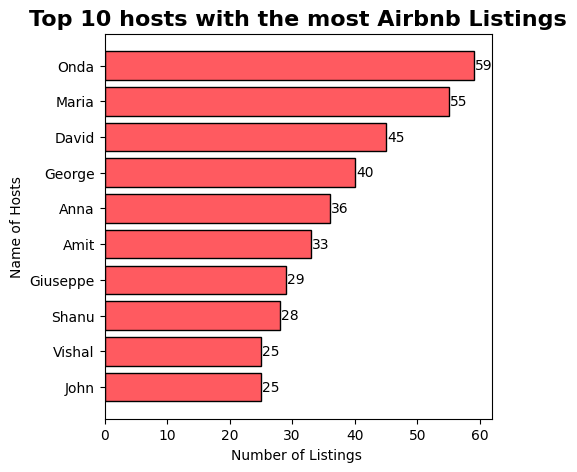

In [154]:
plt.figure(figsize=(5,5))
plt.bar_label((plt.barh(
    host_listings['host_name'],
    host_listings['listing_count'],
    color="#FF5A60",
    edgecolor='black')),
              fmt="%.0f",
              padding=1)

plt.title('Top 10 hosts with the most Airbnb Listings',fontsize=16,fontweight='bold')
plt.xlabel('Number of Listings ')
plt.ylabel('Name of Hosts')

plt.gca().invert_yaxis()
plt.show()

### Observation

A small number of hosts manage significantly more Airbnb listings than others, while the majority of hosts appear to operate only a few properties.


### Business Insight

The presence of hosts with single and multiple listings suggest that Airbnb includes both hoemowners and professional property managers. Large scale hosts contribute considerably to the platform.

---
---

## Amenities Analysis

### What are the 10 most common amenities offered by airbnb hosts?

In [155]:
amenities=(df['amenities']
           .dropna()
           .str.split(",")
           .explode()
           .str.strip())
amenities=amenities[~amenities.isin(
    ["Unavailable: Carbon monoxide alarmCarbon monoxide alarm",
     "Unavailable: Smoke alarmSmoke alarm"])]
top_amenities=amenities.value_counts().head(10)
top_amenities

,count
amenities,
Wifi,9881
Kitchen,9640
Free parking on premises,9502
Pets allowed,4666
TV,4589
Air conditioning,4490
Dedicated workspace,4202
Washing machine,3766
Long-term stays allowed,2991


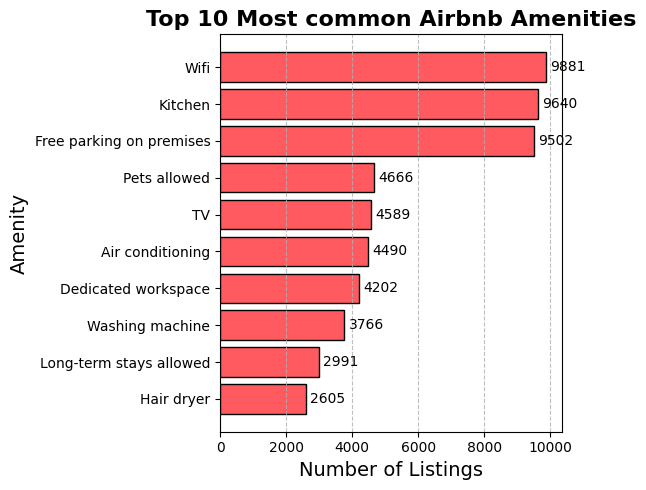

In [156]:
plt.figure(figsize=(6,5))

plt.bar_label((plt.barh(top_amenities.index,
                        top_amenities.values,
                        color='#FF5A60',
                        edgecolor='black')),
              fmt='%.0f',
              padding=3)

plt.title('Top 10 Most common Airbnb Amenities', fontsize=16, fontweight='bold')
plt.xlabel('Number of Listings',fontsize=14)
plt.ylabel('Amenity',fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.8)

plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

### Observation

WiFi, Kitchen and Free Parking on Premises are the three most common amenities, each appearing in over 9500 Airbnb Listings. Amenities such as Pets Allowed, TV, Air conditioning, Dedicated Workspace and Washing Machine are also frequently offered amenities.

### Business Insight

Essential amenities such as WiFi, Kitchen and Parking have become standard providings rather than premium features. The high commonness of these features suggest that guests consider them a part of Airbnb stay.

---
---

### What is the average price of listings offering the top five most common amenities?

In [157]:
top5_amenities = top_amenities.head(5).index.tolist()

top5_amenities

['Wifi', 'Kitchen', 'Free parking on premises', 'Pets allowed', 'TV']

In [158]:
results = []

for amenity in top5_amenities:
    avg_price = (
        df[df["amenities"].str.contains(amenity, case=False, na=False)]["price"]
        .mean()
    )

    listing_count = (
        df["amenities"]
        .str.contains(amenity, case=False, na=False)
        .sum()
    )

    results.append({
        "Amenity": amenity,
        "Average Price": avg_price.round(2),
        "Listings": listing_count
    })

amenity_price = (
    pd.DataFrame(results)
      .sort_values("Average Price", ascending=False)
)

amenity_price

,Amenity,Average Price,Listings
4,TV,21383.00,7578
1,Kitchen,19863.98,9640
0,Wifi,18847.24,10384
2,Free parking on premises,17383.05,9567
3,Pets allowed,15864.46,4666


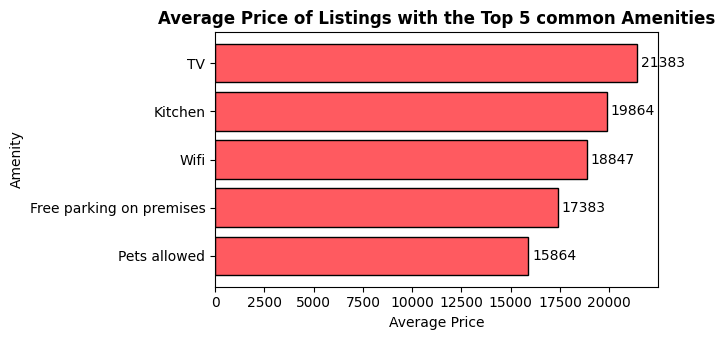

In [159]:
plt.figure(figsize=(7,3.5))

bars = plt.barh(
    amenity_price["Amenity"],
    amenity_price["Average Price"],
    edgecolor="black",
    color='#FF5A60'
)

plt.bar_label(bars, fmt="%.0f", padding=3)

plt.title("Average Price of Listings with the Top 5 common Amenities", fontweight="bold")
plt.xlabel("Average Price")
plt.ylabel("Amenity")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Observation

Among the top 5 common amenities, listings that offer TV have the highest average price **(₹21,385)**, followed by Kitchen **(₹19,864)** and Wifi **(18,847)**. Listings offering 'Pets allowed' have the lowest average price **(₹15,864)** in this group.

### Business Insight

Although all five amenities are commonly available, the average listing price varies across them. This suggests that soem amenities are more frequently associated with higher priced properties than others, reflecting differences in property characteristics and market positioning.

*Note that, this analysis mean that higher priced listings tend to have these amenities and not that this amenities make the listings higher priced.*

---
---

## Price Category Analysis
### How do property characteristics vary across different price categories?

In [160]:
property_comparison=(
    df.groupby('price_category', observed=False)
    .agg(
        Average_guests=('guests','mean'),
        Average_bedrooms=('bedrooms','mean'),
        Average_beds=('beds','mean'),
        Average_bathrooms=('bathrooms','mean')
        ).round(2)
)
property_comparison

,Average_guests,Average_bedrooms,Average_beds,Average_bathrooms
price_category,,,,
Budget,4.08,1.71,1.72,2.16
Standard,5.16,2.07,2.06,2.25
Premium,7.39,3.12,3.12,3.15
Luxury,11.02,5.84,5.82,5.41


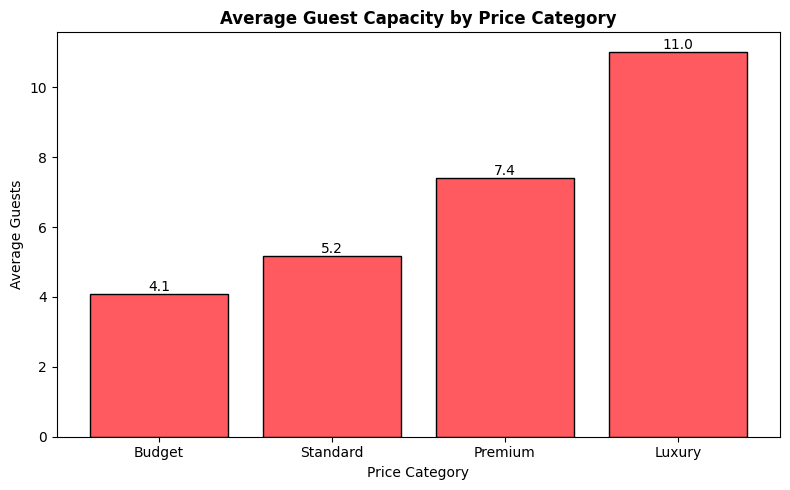

In [161]:
avg_guests = (
    df.groupby("price_category", observed=False)["guests"]
      .mean()
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    avg_guests.index,
    avg_guests.values,
    edgecolor="black",
    color="#FF5A60"
)

plt.bar_label(bars, fmt="%.1f")

plt.title("Average Guest Capacity by Price Category", fontweight="bold")
plt.xlabel("Price Category")
plt.ylabel("Average Guests")

plt.tight_layout()
plt.show()

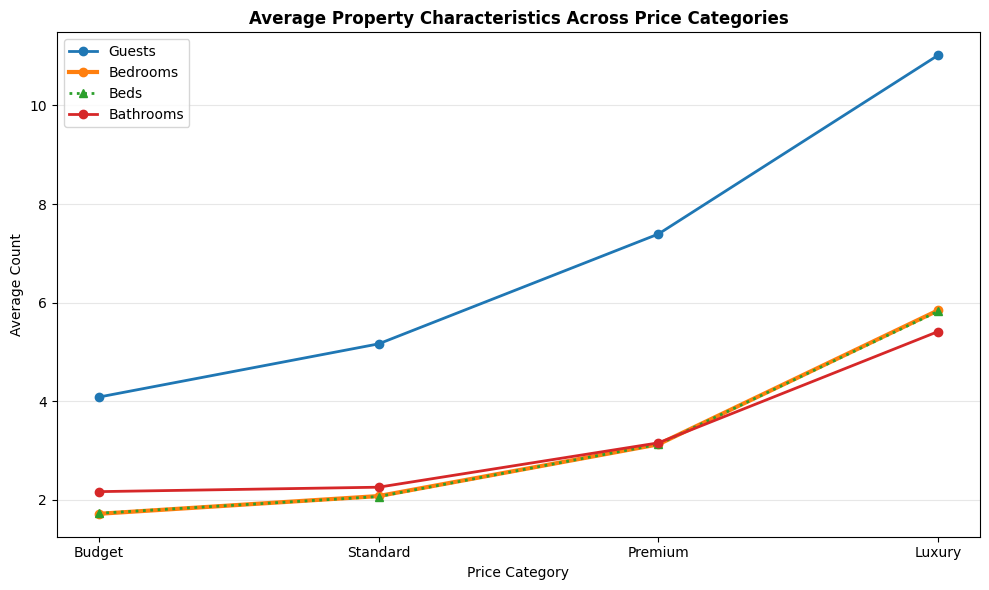

In [162]:
plt.figure(figsize=(10,6))

plt.plot(property_comparison.index, property_comparison["Average_guests"],
         marker="o", linewidth=2, label="Guests")

plt.plot(property_comparison.index, property_comparison["Average_bedrooms"],
         marker="o", linewidth=3, label="Bedrooms")

plt.plot(property_comparison.index, property_comparison["Average_beds"],
         marker="^", linewidth=2, linestyle=":",label="Beds")

plt.plot(property_comparison.index, property_comparison["Average_bathrooms"],
         marker="o", linewidth=2, label="Bathrooms")

plt.title("Average Property Characteristics Across Price Categories",
          fontweight="bold")
plt.xlabel("Price Category")
plt.ylabel("Average Count")

plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Observation

Property characteristics increase consistently across price categories. Luxury listings accomodate more guests and offer significantly more bedrooms, beds and bathrooms than Budget and Standard Listings.


### Business Insight

Higher Priced Airbnb Listings are generally larger properties designed for larger groups. Property size and capacity can be seen strongly associating with higher price categories.

### Recommendation

To optimize revenue, hosts must set their pricing against properties of comparable size and capacity; larger accommodations can ask for premium rates when they can align with the market's comparable listings.

## Customer Reviews Analysis



*   ### Do higher-rated Airbnb listings receive more customer reviews?
*   ### How does customer review activity vary across different Airbnb rating groups?



In [163]:
review_rating=(
    df.dropna(subset=['rating','reviews'])
    .groupby('rating', observed=False)
    .agg(
        Average_Reviews=('reviews','mean'),
        Listings=('rating','count')
    )
    .query('Listings >=50')
    .reset_index()
)
review_rating['Average_Reviews']=review_rating['Average_Reviews'].round(2)
review_rating

,rating,Average_Reviews,Listings
0,4.56,39.26,62
1,4.57,33.63,79
2,4.60,23.55,115
3,4.62,56.13,53
4,4.63,54.19,80
5,4.64,48.56,71
6,4.65,65.19,58
7,4.67,22.65,298
8,4.68,74.98,57
9,4.69,61.95,77


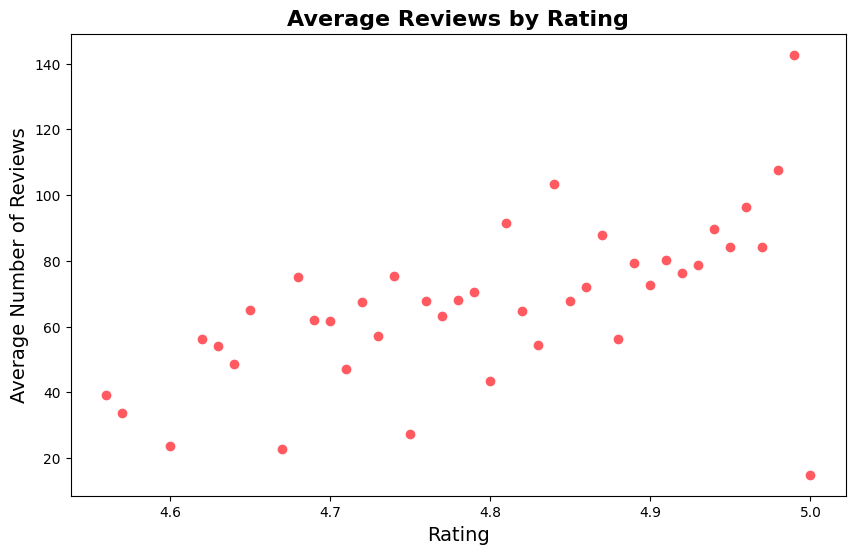

In [164]:
plt.figure(figsize=(10,6))

plt.scatter(review_rating['rating'],
            review_rating['Average_Reviews'],
            color='#FF5A60',
            alpha=1
            )

plt.title("Average Reviews by Rating",fontsize=16, fontweight='bold')
plt.xlabel('Rating',fontsize=14)
plt.ylabel('Average Number of Reviews',fontsize=14)

plt.show()

In [165]:
review_rating['Average_Reviews'].corr(review_rating['rating'])

np.float64(0.5867370208269276)

### Observation

There is a moderate positive correlation (r=0.5724) between Airbnb ratings and average customer reviews. Listings rated between 4.8 and 4.99 generally receive more reviews than lower-rated listings.

***However, listings with a perfect 5.00 rating have a noticeably lower average review count, suggesting that many of these may be newer listings with fewer guest reviews.***

In [166]:
rating_bins=[4.5,4.6,4.7,4.8,4.9,5.00]
rating_labels=[
    '4.50-4.59',
    '4.60-4.69',
    '4.70-4.79',
    '4.80-4.89',
    '4.90-5.00'
]
df['rating_group']= pd.cut(
    df['rating'],
    bins=rating_bins,
    labels=rating_labels,
    include_lowest=True,
    right=False
)

In [167]:
rating_group_reviews=(
    df.dropna(subset=['rating', 'reviews'])
    .groupby('rating_group',observed=False)
    .agg(
        Average_reviews=('reviews','mean'),
        listings=('rating','count')
    )
    .round(2)
    .reset_index()
)
rating_group_reviews

,rating_group,Average_reviews,listings
0,4.50-4.59,51.12,378
1,4.60-4.69,43.31,885
2,4.70-4.79,56.18,1272
3,4.80-4.89,69.53,2155
4,4.90-5.00,87.34,2357


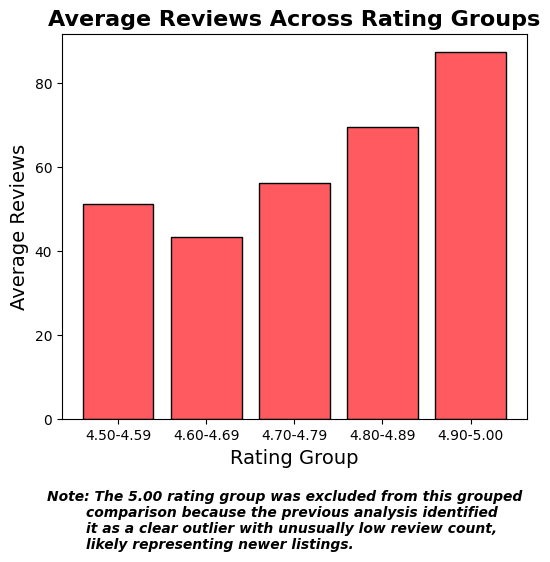

In [168]:
plt.figure(figsize=(6,5))

plt.bar(
    rating_group_reviews['rating_group'],
    rating_group_reviews['Average_reviews'],
    edgecolor='black',
    color='#FF5A60'
)
plt.figtext(
    0.1,-0.15,
    "Note: The 5.00 rating group was excluded from this grouped "
    "\n        comparison because the previous analysis identified "
    "\n        it as a clear outlier with unusually low review count,"
    "\n        likely representing newer listings.",
    fontstyle='italic',
    fontweight='bold'
)
plt.title('Average Reviews Across Rating Groups',fontsize=16, fontweight='bold')
plt.xlabel('Rating Group', fontsize=14)
plt.ylabel('Average Reviews',fontsize=14)
plt.show()

### Observation

Average customer reviews generally increase with higher rating groups. Listings rated between 4.90 and 4.99 receive the highest average number of reviews, while lower-rated groups receive comparatively fewer reviews.


### Business Insight

Higher rated listings tend to attract greater customer engagement, as reflected by their higher average review counts. This suggests that maintaining consistently high ratings may contribute to increased guest trust and listing visibility.

---
---

## **Key Findings**



* **Budget Listings dominate the Airbnb Marketplace**, accounting for the largest share of available properties.
*  **Property size increases consistently with price category**. Luxury listings accommodate more guests and offer more beds, bedrooms and bathrooms.
*  **Switzerland and the United Arab Emirates** have the highest average listing prices among countries with at least 50 listings.
*  **WiFi, Kitchen and Free Parking on Premises** are the most commonly offered amenities, indicating they are standard guest expectations.
*  **Listings offering the top 5 most common amenities **generally have different average prices, suggesting that amenities are associated with property positioning and pricing.
*  **A moderate positive correlation (r = 0.5724) **exists between ratings and customer reviews, indicating that higher-rated listings tend to receive greater guest engagement.
*  **A small number of hosts manage a disproportionately large number of listings**, highlighting the presence of professional property managers alongside individual hosts.


---

## **Business Recommendation**

*  **Hosts should benchmark prices against comparable properties** with similar size, guest capacity and location rather than relying on global averages.
*  Essential amenities such as **WiFi, Kitchen and Free Parking** should be treated as baseline offerings, as they are widely available across competing listings.
*  **Maintaining consistently high guest ratings can improve long-term engagement**, as higher-rated listings are generally associated with more customer reviews.
* **Pricing strategies should consider both property characteristics and local market conditions,** since listing size and country level differences have a significant impact on average prices.
* Airbnb can leverage country-level pricing trends and property characteristics to provide more accurate pricing recommendations for hosts.

---

# **Conclusion**

This project analyzed **Airbnb** listing data to identify the key factors influencing pricing, customer engagement and property characteristics. **Using Python libraries**- `Pandas`,`NumPy` and `Matplotlib`, the analysis revealed meaningful relationships between property size, amenities, location, ratings and listing prices. The insights can help hosts make informed pricing decisions while providing a better understanding of market trends across different segments of the Airbnb marketplace.

---
---
---